# 📈 Stock Market Analysis Project

### 🔍 Overview:
This project focuses on analyzing historical stock market data to understand trends, price movements, and trading patterns using Python data analysis tools.

### 🎯 Objective:
- To explore stock performance and extract meaningful insights through visualization and statistical analysis.

### 📊 Key Features:
- Data cleaning and preprocessing of stock datasets
- Exploratory Data Analysis (EDA)
- Visualization of closing prices, volume, and trends
- Moving average analysis
- (Optional) Basic prediction/forecasting using ML models

### 🛠️ Tools & Libraries Used:
- Python
- Pandas & NumPy
- Matplotlib & Seaborn
- (Optional) Scikit-learn / Yahoo Finance API

### 📌 Outcome:
Helps in understanding stock behavior and supports data-driven decision making
through visual insights and trend analysis.

In [1]:
# Importing necessary libraries for data handling, visualization, and building a linear regression model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
from google.colab import files
_ = files.upload()

Saving stocks.csv to stocks.csv


In [4]:
# Loading the stock market dataset from a CSV file into a pandas DataFrame
stock = pd.read_csv(r'stocks.csv')
stock

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


In [5]:
# Displaying dataset structure, data types, and missing values information
stock.info()

# Displaying the first 5 rows of the dataset to understand its content
stock.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [6]:
# Checking for missing values in each column of the stock dataset
stock.isnull().sum()

,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [7]:
# Removing all rows that contain missing (NaN) values from the dataset
stock = stock.dropna()

In [8]:
# Converting 'Date' column into datetime format for proper time-series analysis
stock['Date'] = pd.to_datetime(stock['Date'])

# Converting datetime values into ordinal numbers so they can be used in ML models
stock['Date'] = stock['Date'].map(pd.Timestamp.toordinal)

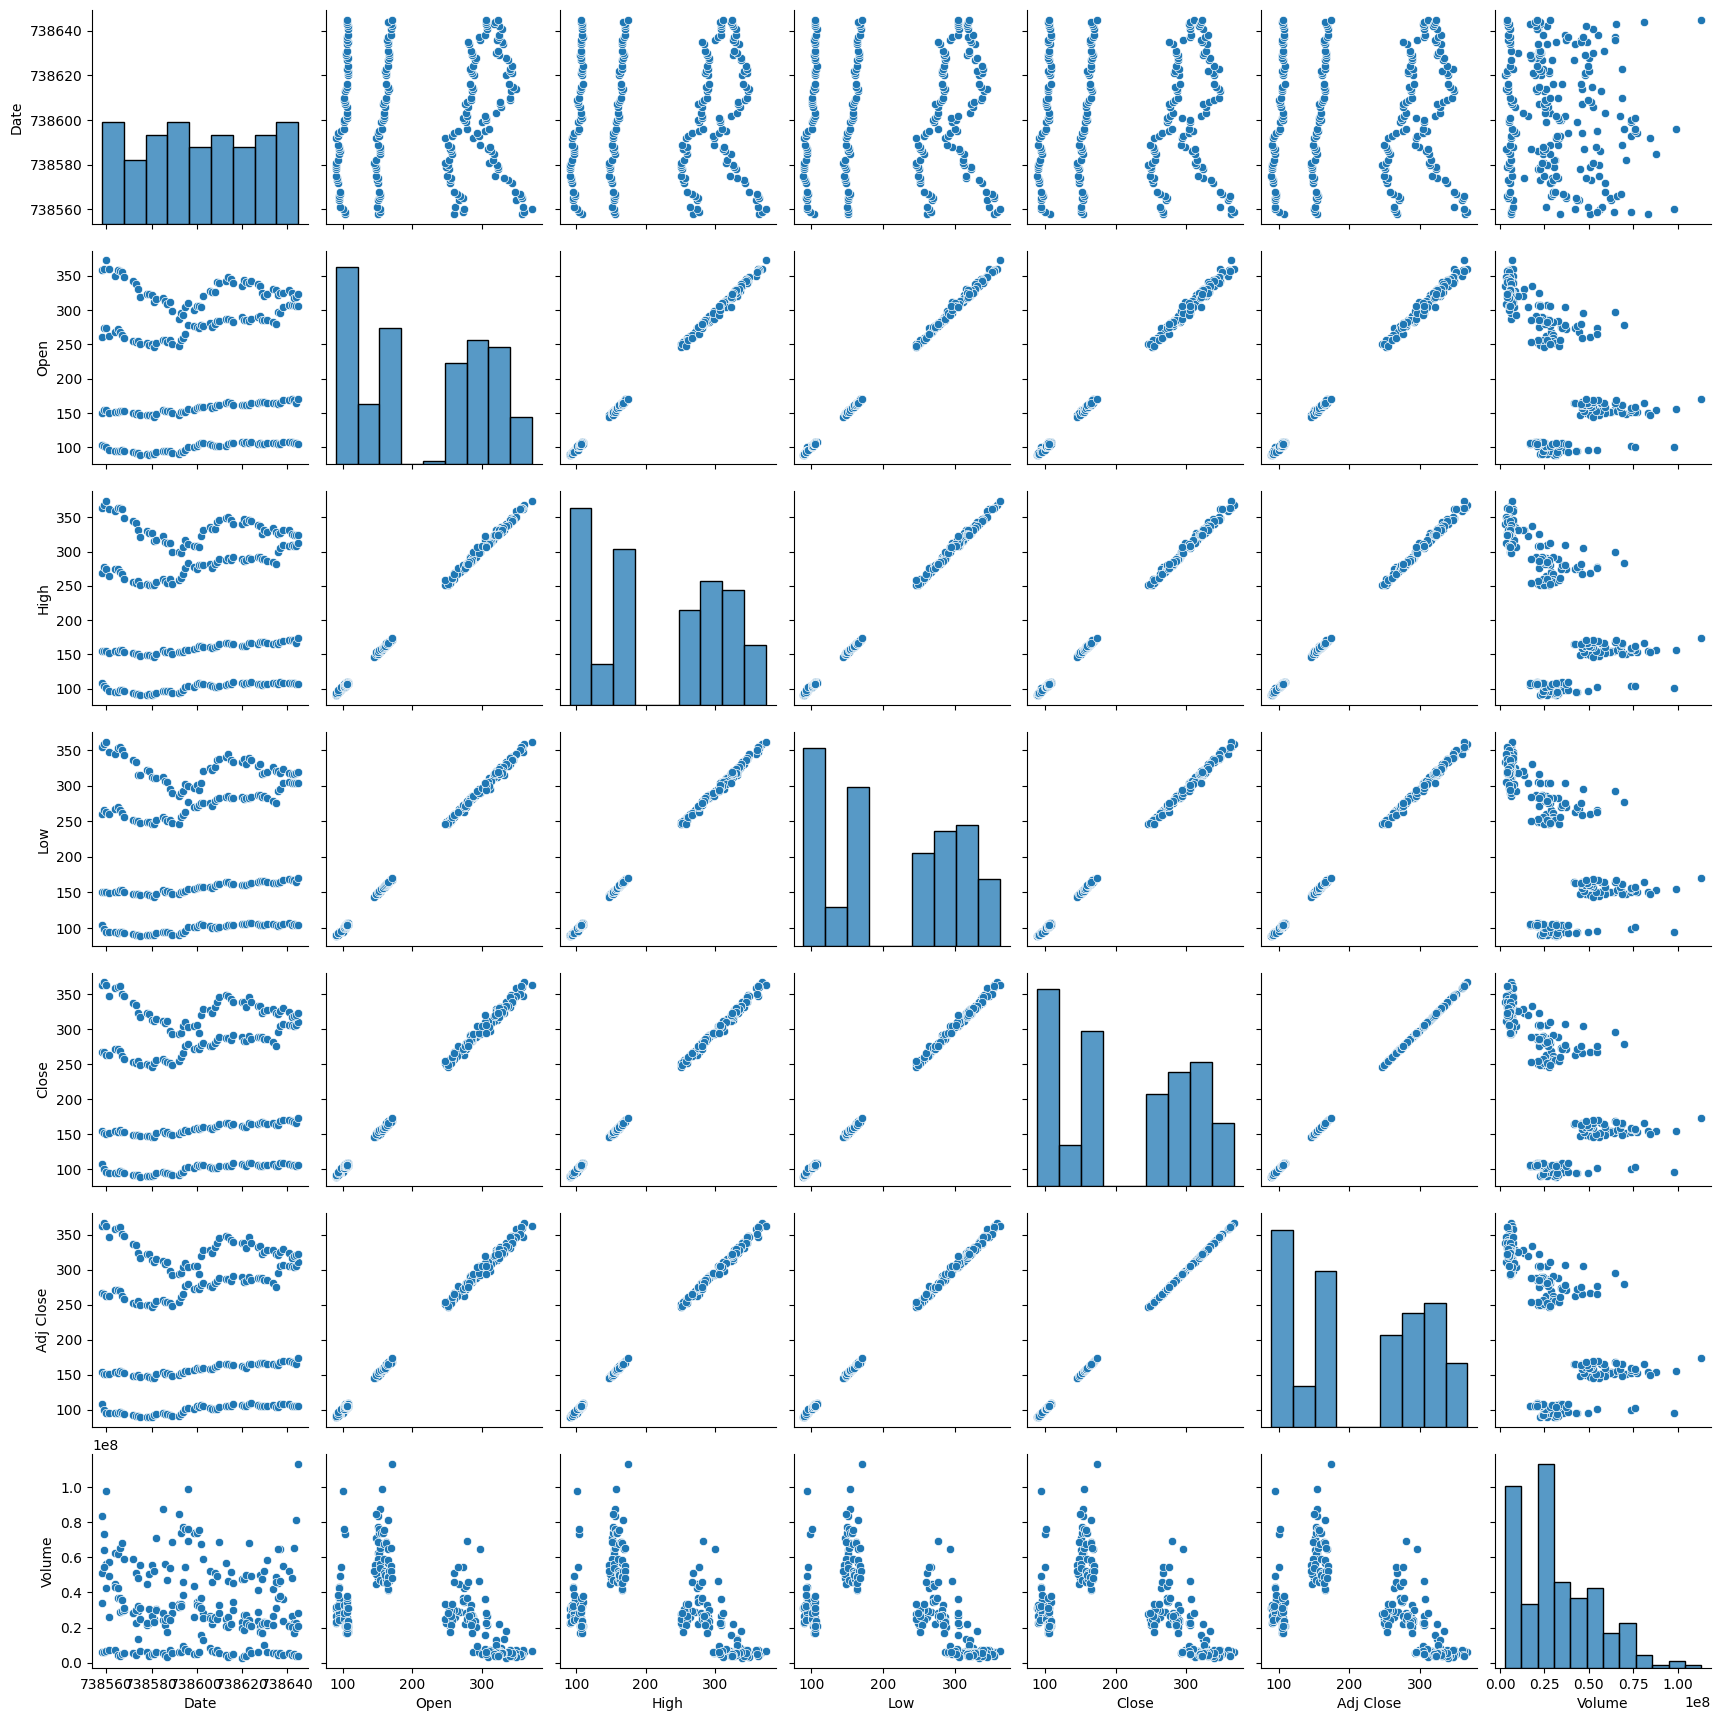

In [9]:
# Creating pairplot to visualize relationships between variables in the stock dataset
sns.pairplot(stock)
plt.show()

In [10]:
# Splitting the dataset into input features (X) and target variable (y)
# X contains independent variables used to predict stock closing price
# y contains the dependent variable (Close price)

x = stock[['Date', 'Open', 'High', 'Low', 'Volume']]
y = stock['Close']

In [11]:
# Splitting the dataset into training and testing sets
# 80% data is used for training the model and 20% is used for testing
# random_state ensures reproducibility of the split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
# Creating a Linear Regression model and training it using the training data
# The model learns the relationship between input features (x_train) and target (y_train)

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [13]:
# Using the trained Linear Regression model to predict stock closing prices on test data
predictions = model.predict(x_test)

In [14]:
# Creating a DataFrame to compare actual vs predicted stock closing prices
# This helps in evaluating model performance visually and numerically

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

# Displaying first few comparison results
results.head()

,Actual Price,Predicted Price
33,158.279999,159.064155
6,155.330002,154.528240
182,317.549988,318.949914
86,260.790009,259.448617
156,328.390015,329.321612


In [15]:
# Evaluating model performance using Mean Absolute Error (MAE)
# MAE measures the average absolute difference between actual and predicted values

print("MAE:", metrics.mean_absolute_error(y_test, predictions))

MAE: 1.165201889521924


In [16]:
# Evaluating model performance using Mean Squared Error (MSE)
# MSE measures the average squared difference between actual and predicted values

print("MSE:", metrics.mean_squared_error(y_test, predictions))

MSE: 2.422103570624966


In [17]:
# Evaluating model performance using Root Mean Squared Error (RMSE)
# RMSE gives error in the same units as the target variable (stock price)

print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

RMSE: 1.5563108849535705


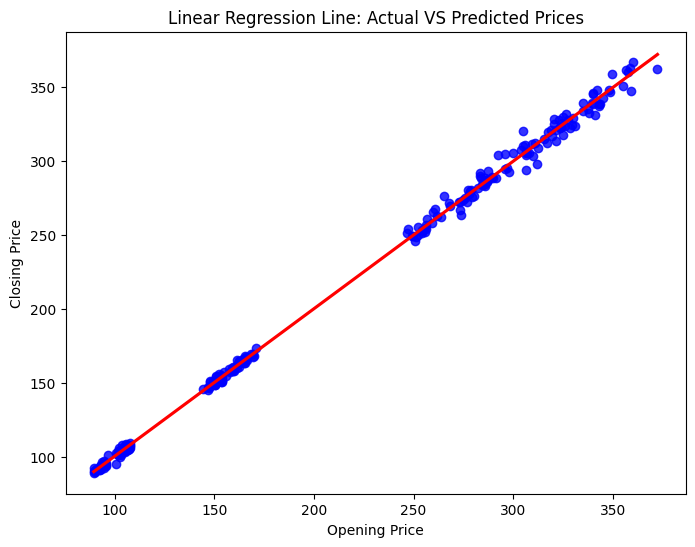

In [18]:
# Visualizing relationship between Opening Price and Closing Price using regression plot
# The red line shows the best fit line (linear regression trend)

plt.figure(figsize=(8,6))

sns.regplot(
    x='Open',
    y='Close',
    data=stock,
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"}
)

plt.title("Linear Regression Line: Actual VS Predicted Prices")
plt.xlabel("Opening Price")
plt.ylabel("Closing Price")

plt.show()